# MNIST: cross-validation with a multilayer perceptron

A single validation split gives one estimate of how well a model generalizes. That estimate can depend on which examples happened to enter the validation set. In this notebook, we use **stratified $k$-fold cross-validation** to measure that variation and to compare two multilayer perceptrons (MLPs) without consulting the test set.

This is a **tutorial notebook** intended to follow `mnist_mlp.ipynb`. The default workflow takes approximately 10–20 minutes on a typical CPU, including interpretation; the full experiment is substantially more expensive.

## Learning objectives

After completing the notebook, you should be able to:

- explain what changes between folds and what remains fixed;
- implement stratified $k$-fold cross-validation without leaking information between folds;
- compare candidate models using paired folds and summarize fold-to-fold variation;
- keep the test set outside model selection and use it only after the choice is frozen;
- recognize when ordinary random cross-validation is inappropriate or unnecessarily expensive.

## Prerequisites and expected output

**Required:** the train/validation/test distinction, PyTorch datasets and data loaders, and the MLP training loop introduced in `mnist_mlp.ipynb`.

**Helpful, but not required:** familiarity with means, standard deviations, and class stratification.

The notebook produces per-fold loss and accuracy, a paired comparison of a classic and dropout MLP, and one final test-set result. It downloads MNIST into `data/` if necessary. No package installation is performed inside the notebook.

## Experimental design

The official MNIST training split is our source of **development data**. We divide the working development set into $k$ folds. Each fold becomes the validation fold once, while the other $k-1$ folds are used for training.

The official test split is not one of the folds. It remains untouched until we have selected a model configuration and fitted that configuration one final time.

The quick configuration uses a stratified subset of the official training split so that repeated training remains practical during a course. This makes the notebook a demonstration of the method, not an attempt to obtain the best possible MNIST model. Set `FULL_EXPERIMENT = True` to cross-validate on all 60,000 development examples.

In [1]:
from collections.abc import Callable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets
from torchvision.transforms import v2

## Configuration

Five folds make the mechanics and the fold-to-fold variation visible. The quick path deliberately uses a small model, a subset, and only three epochs. Cross-validation multiplies training cost: comparing two candidates with five folds requires ten independent fits before the final refit.

In [2]:
FULL_EXPERIMENT = False

N_SPLITS = 5
DEVELOPMENT_EXAMPLES = None if FULL_EXPERIMENT else 12_000
EPOCHS = 10 if FULL_EXPERIMENT else 3
BATCH_SIZE = 256
LEARNING_RATE = 0.05
MOMENTUM = 0.9

SPLIT_SEED = 1_734
MODEL_SEED = 2_741
LOADER_SEED = 3_907
FINAL_MODEL_SEED = 4_997

## Reproducibility and device selection

Fixed seeds make the data splits and CPU runs reproducible under the same software and hardware configuration. Exact results can still differ across PyTorch versions and devices. We pass transfer settings explicitly so that data-loader memory pinning and device transfers remain distinct concerns.

In [3]:
torch.manual_seed(MODEL_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
using_cuda = device.type == "cuda"
print(f"Using device: {device}")

Using device: cuda


## Prepare the data

The transformation converts each image to a `float32` tensor in channels-first format and scales pixel values to $[0, 1]$. The labels remain integer class indices, as required by `nn.CrossEntropyLoss`.

In [4]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

official_development_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)
official_test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

all_development_targets = official_development_data.targets.numpy()
print(f"Official development examples: {len(official_development_data):,}")
print(f"Official test examples:        {len(official_test_data):,}")

Official development examples: 60,000
Official test examples:        10,000


### Select the working development set

In quick mode, `StratifiedShuffleSplit` selects a smaller working set while approximately preserving the digit proportions. The remaining official training examples are simply unused in this demonstration; they are **not** silently treated as test data.

In [5]:
if DEVELOPMENT_EXAMPLES is None:
    development_positions = np.arange(len(official_development_data))
else:
    subset_splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=DEVELOPMENT_EXAMPLES,
        random_state=SPLIT_SEED,
    )
    development_positions, _ = next(
        subset_splitter.split(
            np.zeros(len(official_development_data)),
            all_development_targets,
        )
    )

development_data = Subset(
    official_development_data,
    development_positions.tolist(),
)
development_targets = all_development_targets[development_positions]

print(f"Working development examples: {len(development_data):,}")
print(
    "Class counts:",
    np.bincount(development_targets, minlength=10).tolist(),
)

Working development examples: 60,000
Class counts: [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]


## Construct the folds

`StratifiedKFold` keeps the class proportions approximately equal across folds. Shuffling before splitting avoids folds that depend on the original storage order, while `random_state` makes the fold assignment reproducible.

Each example must occur in exactly one validation fold. With 12,000 examples and five folds, predict the number of training and validation examples in each fit before running the next cell.

In [6]:
splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SPLIT_SEED,
)
folds = list(
    splitter.split(
        np.zeros(len(development_data)),
        development_targets,
    )
)

validation_positions = np.concatenate(
    [validation for _, validation in folds]
)
assert len(validation_positions) == len(development_data)
assert np.array_equal(
    np.sort(validation_positions),
    np.arange(len(development_data)),
)

fold_sizes = pd.DataFrame(
    [
        {
            "fold": fold_number,
            "training examples": len(training),
            "validation examples": len(validation),
        }
        for fold_number, (training, validation) in enumerate(folds, start=1)
    ]
)
display(fold_sizes)

,fold,training examples,validation examples
0,1,48000,12000
1,2,48000,12000
2,3,48000,12000
3,4,48000,12000
4,5,48000,12000


## Define the candidate MLPs

Both candidates have the same linear layers. The second adds dropout after each hidden activation. Keeping the architecture simple lets us focus on the experimental design rather than on image-specific CNN details.

A model factory is crucial: calling it creates a **new model with new parameters** for every fold. Reusing a trained model would leak information from earlier validation folds into later fits.

In [7]:
class MnistMLP(nn.Module):
    def __init__(self, dropout_probability: float = 0.0) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(64, 10),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        return self.layers(images)


def make_classic_mlp() -> nn.Module:
    return MnistMLP(dropout_probability=0.0)


def make_dropout_mlp() -> nn.Module:
    return MnistMLP(dropout_probability=0.25)


model_factories: dict[str, Callable[[], nn.Module]] = {
    "classic": make_classic_mlp,
    "dropout": make_dropout_mlp,
}

parameter_count = sum(
    parameter.numel() for parameter in make_classic_mlp().parameters()
)
print(f"Trainable parameters per model: {parameter_count:,}")

Trainable parameters per model: 109,386


## Training and evaluation helpers

The helpers aggregate loss and accuracy by example rather than averaging batch averages. Every relevant execution setting is passed explicitly. Validation loaders are not shuffled because ordering does not affect their metrics.

In [8]:
def make_loader(
    dataset: Dataset,
    positions: Sequence[int] | np.ndarray,
    *,
    shuffle: bool,
    seed: int,
    batch_size: int,
    pin_memory: bool,
) -> DataLoader:
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        Subset(dataset, list(positions)),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        pin_memory=pin_memory,
        num_workers=0,
    )


def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    *,
    device: torch.device,
    non_blocking: bool,
) -> dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=non_blocking)
        targets = targets.to(device, non_blocking=non_blocking)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = loss_function(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }


@torch.inference_mode()
def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    *,
    device: torch.device,
    non_blocking: bool,
) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=non_blocking)
        targets = targets.to(device, non_blocking=non_blocking)
        logits = model(images)
        loss = loss_function(logits, targets)

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }

## Cross-validation function

For every fold, the function:

1. resets the model seed;
2. creates fresh training and validation loaders;
3. creates a fresh model and optimizer;
4. trains for a fixed number of epochs;
5. evaluates once on that fold's validation examples.

We use the same folds, initialization seeds, and training-loader seeds for both candidates. This paired design removes avoidable sources of variation from the comparison. Dropout still makes the two optimization paths differ.

Data-dependent preprocessing belongs inside the fold as well: means, scaling parameters, feature selection, or dimensionality reduction must be learned from the training portion only. The MNIST transformation above merely applies a fixed conversion and scaling rule, so it has no fitted state to leak.

In [9]:
def cross_validate(
    model_name: str,
    model_factory: Callable[[], nn.Module],
    dataset: Dataset,
    folds: Sequence[tuple[np.ndarray, np.ndarray]],
    *,
    epochs: int,
    batch_size: int,
    learning_rate: float,
    momentum: float,
    model_seed: int,
    loader_seed: int,
    device: torch.device,
    pin_memory: bool,
    non_blocking: bool,
) -> pd.DataFrame:
    loss_function = nn.CrossEntropyLoss()
    fold_results = []

    for fold_number, (training_positions, validation_positions) in enumerate(
        folds,
        start=1,
    ):
        torch.manual_seed(model_seed + fold_number)

        training_loader = make_loader(
            dataset,
            training_positions,
            shuffle=True,
            seed=loader_seed + fold_number,
            batch_size=batch_size,
            pin_memory=pin_memory,
        )
        validation_loader = make_loader(
            dataset,
            validation_positions,
            shuffle=False,
            seed=loader_seed + fold_number,
            batch_size=batch_size,
            pin_memory=pin_memory,
        )

        model = model_factory().to(device)
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=momentum,
        )

        for _ in range(epochs):
            training_metrics = train_one_epoch(
                model,
                training_loader,
                loss_function,
                optimizer,
                device=device,
                non_blocking=non_blocking,
            )

        validation_metrics = evaluate(
            model,
            validation_loader,
            loss_function,
            device=device,
            non_blocking=non_blocking,
        )

        fold_results.append(
            {
                "model": model_name,
                "fold": fold_number,
                "training_loss": training_metrics["loss"],
                "training_accuracy": training_metrics["accuracy"],
                "validation_loss": validation_metrics["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
            }
        )
        print(
            f"{model_name:>7s}, fold {fold_number}: "
            f"val_loss={validation_metrics['loss']:.4f}, "
            f"val_accuracy={validation_metrics['accuracy']:.4f}"
        )

    return pd.DataFrame(fold_results)

## Run the paired comparison

Before running the cell, make two predictions:

- Will the candidate with the highest training accuracy necessarily have the best mean validation loss?
- Will one candidate win on every fold?

The selection rule is declared in advance: **select the candidate with the lowest mean validation loss**. The test set plays no role in this decision.

In [10]:
candidate_results = []

for model_name, model_factory in model_factories.items():
    print(f"Cross-validating {model_name} MLP")
    candidate_results.append(
        cross_validate(
            model_name,
            model_factory,
            development_data,
            folds,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            momentum=MOMENTUM,
            model_seed=MODEL_SEED,
            loader_seed=LOADER_SEED,
            device=device,
            pin_memory=using_cuda,
            non_blocking=using_cuda,
        )
    )
    print()

cross_validation_results = pd.concat(candidate_results, ignore_index=True)
display(cross_validation_results.round(4))

Cross-validating classic MLP
classic, fold 1: val_loss=0.0814, val_accuracy=0.9758
classic, fold 2: val_loss=0.0906, val_accuracy=0.9748
classic, fold 3: val_loss=0.0847, val_accuracy=0.9764
classic, fold 4: val_loss=0.0873, val_accuracy=0.9746
classic, fold 5: val_loss=0.0962, val_accuracy=0.9742

Cross-validating dropout MLP
dropout, fold 1: val_loss=0.0832, val_accuracy=0.9743
dropout, fold 2: val_loss=0.0892, val_accuracy=0.9752
dropout, fold 3: val_loss=0.0867, val_accuracy=0.9742
dropout, fold 4: val_loss=0.0929, val_accuracy=0.9714
dropout, fold 5: val_loss=0.0965, val_accuracy=0.9737



,model,fold,training_loss,training_accuracy,validation_loss,validation_accuracy
0,classic,1,0.0351,0.9894,0.0814,0.9758
1,classic,2,0.0328,0.9900,0.0906,0.9748
2,classic,3,0.0337,0.9900,0.0847,0.9764
3,classic,4,0.0327,0.9901,0.0873,0.9746
4,classic,5,0.0334,0.9893,0.0962,0.9742
5,dropout,1,0.0992,0.9692,0.0832,0.9743
6,dropout,2,0.0963,0.9709,0.0892,0.9752
7,dropout,3,0.0965,0.9700,0.0867,0.9742
8,dropout,4,0.0924,0.9719,0.0929,0.9714
9,dropout,5,0.0965,0.9698,0.0965,0.9737


## Summarize fold-to-fold variation

The mean summarizes performance across folds. The sample standard deviation describes how much the score changed when the validation examples changed. It is not, by itself, a confidence interval for future performance.

Because both candidates used identical folds, compare them within each fold as well as through their means.

In [11]:
summary = (
    cross_validation_results.groupby("model")
    .agg(
        mean_loss=("validation_loss", "mean"),
        std_loss=("validation_loss", "std"),
        mean_accuracy=("validation_accuracy", "mean"),
        std_accuracy=("validation_accuracy", "std"),
    )
    .sort_values("mean_loss")
)
display(summary.round(4))

,mean_loss,std_loss,mean_accuracy,std_accuracy
model,,,,
classic,0.0881,0.0057,0.9752,0.0009
dropout,0.0897,0.0052,0.9738,0.0014


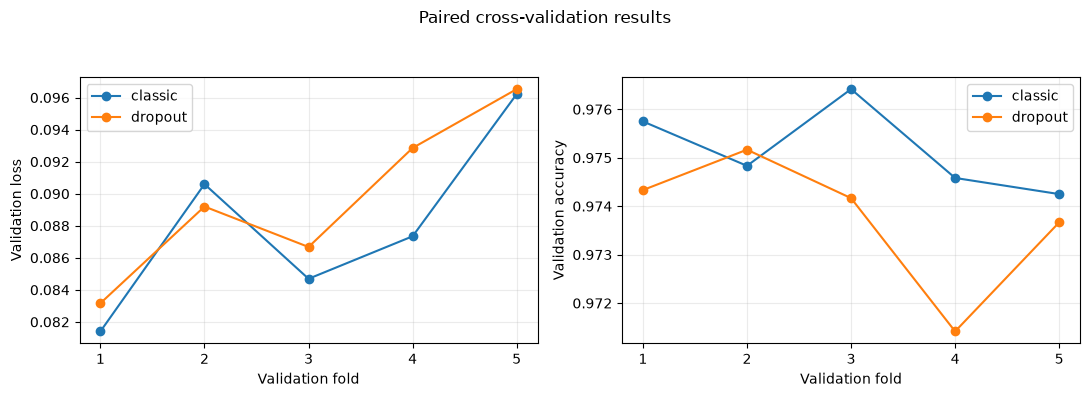

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))

for model_name, results in cross_validation_results.groupby("model"):
    axes[0].plot(
        results["fold"],
        results["validation_loss"],
        marker="o",
        label=model_name,
    )
    axes[1].plot(
        results["fold"],
        results["validation_accuracy"],
        marker="o",
        label=model_name,
    )

axes[0].set(
    xlabel="Validation fold",
    ylabel="Validation loss",
    xticks=range(1, N_SPLITS + 1),
)
axes[1].set(
    xlabel="Validation fold",
    ylabel="Validation accuracy",
    xticks=range(1, N_SPLITS + 1),
)
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
figure.suptitle("Paired cross-validation results")
figure.tight_layout(rect=(0, 0, 1, 0.93))

### Interpreting the comparison

A small difference in mean performance should not be treated as decisive when it is comparable to the fold-to-fold variation. Inspect whether the models differ consistently on the same folds, and consider runtime, model complexity, and the scientific cost of different errors.

Cross-validation reduces dependence on one arbitrary split; it does not eliminate optimization randomness. Repeating the entire cross-validation experiment with new initialization seeds would measure an additional source of variation, at a substantial computational cost.

## Freeze the choice, then use the test set once

We now select the candidate with the lowest mean validation loss, create a fresh instance, and fit it on the entire **working development set**. In quick mode that is the stratified subset selected earlier; the unused official training examples remain unused. In full mode it is all 60,000 official training examples.

We keep the epoch count fixed. If we used the scored validation fold for early stopping, it would influence both training and evaluation and make the fold score optimistic. A sound early-stopping workflow needs a further inner split inside each training fold—or a nested cross-validation design.

After the next cell evaluates the official test set, do not use that result to change the architecture, dropout probability, learning rate, or epoch count. Doing so would turn the test set into another validation set.

In [13]:
selected_name = summary["mean_loss"].idxmin()
selected_factory = model_factories[selected_name]
print(f"Selected candidate: {selected_name}")

torch.manual_seed(FINAL_MODEL_SEED)
selected_model = selected_factory().to(device)
final_optimizer = torch.optim.SGD(
    selected_model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
)
loss_function = nn.CrossEntropyLoss()

final_training_loader = make_loader(
    development_data,
    np.arange(len(development_data)),
    shuffle=True,
    seed=LOADER_SEED,
    batch_size=BATCH_SIZE,
    pin_memory=using_cuda,
)

for epoch in range(1, EPOCHS + 1):
    final_training_metrics = train_one_epoch(
        selected_model,
        final_training_loader,
        loss_function,
        final_optimizer,
        device=device,
        non_blocking=using_cuda,
    )
    print(
        f"Epoch {epoch:2d}/{EPOCHS}: "
        f"loss={final_training_metrics['loss']:.4f}, "
        f"accuracy={final_training_metrics['accuracy']:.4f}"
    )

Selected candidate: classic
Epoch  1/10: loss=0.5976, accuracy=0.8230
Epoch  2/10: loss=0.1875, accuracy=0.9436
Epoch  3/10: loss=0.1243, accuracy=0.9637
Epoch  4/10: loss=0.0966, accuracy=0.9712
Epoch  5/10: loss=0.0770, accuracy=0.9774
Epoch  6/10: loss=0.0619, accuracy=0.9812
Epoch  7/10: loss=0.0527, accuracy=0.9839
Epoch  8/10: loss=0.0431, accuracy=0.9873
Epoch  9/10: loss=0.0377, accuracy=0.9885
Epoch 10/10: loss=0.0311, accuracy=0.9909


In [14]:
test_loader = DataLoader(
    official_test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=using_cuda,
    num_workers=0,
)
test_metrics = evaluate(
    selected_model,
    test_loader,
    loss_function,
    device=device,
    non_blocking=using_cuda,
)
print(f"Final test loss:     {test_metrics['loss']:.4f}")
print(f"Final test accuracy: {test_metrics['accuracy']:.4f}")

Final test loss:     0.0694
Final test accuracy: 0.9788


## When ordinary $k$-fold cross-validation is not the right tool

Cross-validation is useful when a single split would waste scarce data or give an unstable comparison. It is not automatically the best default for deep learning:

- repeated fitting may be prohibitively expensive for large models and datasets;
- a sufficiently large, representative validation set may already give a stable estimate;
- ordinary random folds are invalid when related observations can cross folds—for example, images from the same patient, measurements from the same instrument run, or nearby time points;
- temporal forecasting requires splits that respect time order;
- extensive hyperparameter search can overfit the cross-validation results, requiring nested cross-validation or a separate audit set for an unbiased performance estimate.

The splitter must reflect how genuinely new data will arrive. Stratification balances labels, but it does not repair group, spatial, or temporal dependence.

## Interpretation and transfer questions

Timebox: 10 minutes. Use the tables and plot rather than rerunning the test evaluation.

1. Did the candidate with the best training accuracy also achieve the lowest mean validation loss? Explain why these can disagree.
2. Was the difference between candidates large relative to fold-to-fold variation? What claim is justified by these five folds?
3. What information would leak if the same model instance were trained continuously across folds?
4. Suppose every patient contributed five images. Which part of this notebook would need to change, and why is stratification alone insufficient?
5. If early stopping were essential, sketch a split hierarchy that keeps each outer validation fold independent.

Expected evidence of completion: an explanation of the selection decision, one limitation of the estimate, and an appropriate splitter for grouped data.

<details>
<summary>Suggested answers</summary>

1. Not necessarily. Higher training accuracy can indicate greater capacity or overfitting; validation loss evaluates predictive distributions on unseen fold data.
2. Compare the paired fold results and the mean difference with the observed variation. Five folds support a cautious comparison on this working MNIST sample, not a universal claim about either architecture.
3. Later folds would start from parameters that had already learned from examples—including examples later used for validation—so their scores would no longer represent independent held-out evaluation.
4. Replace `StratifiedKFold` with a group-aware splitter such as `StratifiedGroupKFold`, using patient ID as the group. Otherwise images from one patient can appear in both training and validation data.
5. For each outer fold, reserve the outer validation data strictly for scoring. Split only the outer training data again into an inner training and early-stopping set. Nested cross-validation extends this idea when model selection itself needs an unbiased outer estimate.

</details>

## Takeaways

- Cross-validation estimates sensitivity to the development-data split by rotating the held-out fold.
- Every fold needs fresh model and optimizer state.
- Candidate models should use the same folds for a paired comparison.
- Mean and standard deviation summarize the observed folds but do not remove every source of uncertainty.
- The test set remains outside model selection and is evaluated only after the decision is frozen.
- The split strategy must match the dependence structure and deployment setting of the real problem.